# FIFA World Cup 2026 - Objective 1 Data Science Solution

This notebook completes four distinct analytic tasks using the uploaded FBref FIFA World Cup 2026 CSV exports. Each task follows the assessment-required structure: analytic question formulation, data wrangling, data preparation and sampling, descriptive statistics, 95% confidence intervals, and an inferential t-test.

The notebook is intentionally written for assessment evidence: it shows the logic, code, validation checks, assumptions and limitations rather than only final graphs.


## Setup: libraries and helper functions

In [1]:

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('.')
RAW = BASE / 'data' / 'raw'
PROC = BASE / 'data' / 'processed'
FIG = BASE / 'figures'
PROC.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
ALPHA = 0.05

def make_unique(columns):
    counts = {}
    out = []
    for col in columns:
        col = str(col).replace('▼', '').strip()
        if col in counts:
            counts[col] += 1
            out.append(f'{col}.{counts[col]}')
        else:
            counts[col] = 0
            out.append(col)
    return out

def read_fbref_csv(path):
    """Read FBref CSV exports with a grouped header row and a true column-name row."""
    df = pd.read_csv(path, header=1)
    df.columns = make_unique(df.columns)
    df = df.loc[:, ~df.columns.astype(str).str.match('^Unnamed')]
    for c in df.columns:
        if c not in ['Player', 'Pos', 'Squad', 'Club', 'Matches']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df.dropna(how='all').reset_index(drop=True)

def ci_mean(x, confidence=0.95):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf((1 + confidence) / 2, n - 1)
    return pd.Series({'n': n, 'mean': mean, 'sd': sd, 'se': se, 'lower': mean - tcrit*se, 'upper': mean + tcrit*se})

def welch_ci_diff(x1, x2, confidence=0.95):
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)
    n1, n2 = len(x1), len(x2)
    m1, m2 = x1.mean(), x2.mean()
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    se = np.sqrt(v1/n1 + v2/n2)
    df = (v1/n1 + v2/n2)**2 / (((v1/n1)**2)/(n1-1) + ((v2/n2)**2)/(n2-1))
    tcrit = stats.t.ppf((1 + confidence) / 2, df)
    diff = m1 - m2
    return pd.Series({'difference': diff, 'lower': diff - tcrit*se, 'upper': diff + tcrit*se, 'df': df, 'se': se})

def descriptive_table(sample, group_col, value_col):
    return sample.groupby(group_col)[value_col].agg(
        count='count', mean='mean', median='median', std='std', min='min',
        q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75), max='max'
    ).round(3)

def assumption_checks(sample, group_col, value_col, group_order):
    g1 = sample.loc[sample[group_col] == group_order[0], value_col].dropna().astype(float)
    g2 = sample.loc[sample[group_col] == group_order[1], value_col].dropna().astype(float)
    shapiro_1 = stats.shapiro(g1)
    shapiro_2 = stats.shapiro(g2)
    levene = stats.levene(g1, g2)
    q1_1, q3_1 = g1.quantile([0.25, 0.75]); iqr1 = q3_1 - q1_1
    q1_2, q3_2 = g2.quantile([0.25, 0.75]); iqr2 = q3_2 - q1_2
    outliers_1 = ((g1 < q1_1 - 1.5*iqr1) | (g1 > q3_1 + 1.5*iqr1)).sum()
    outliers_2 = ((g2 < q1_2 - 1.5*iqr2) | (g2 > q3_2 + 1.5*iqr2)).sum()
    return pd.Series({
        f'Shapiro p ({group_order[0]})': shapiro_1.pvalue,
        f'Shapiro p ({group_order[1]})': shapiro_2.pvalue,
        'Levene p': levene.pvalue,
        f'IQR outliers ({group_order[0]})': int(outliers_1),
        f'IQR outliers ({group_order[1]})': int(outliers_2),
    })

def run_inference(sample, group_col, value_col, group_order):
    g1 = sample.loc[sample[group_col] == group_order[0], value_col].dropna().astype(float)
    g2 = sample.loc[sample[group_col] == group_order[1], value_col].dropna().astype(float)
    t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    return {
        'descriptive': descriptive_table(sample, group_col, value_col),
        'ci_group1': ci_mean(g1).round(3),
        'ci_group2': ci_mean(g2).round(3),
        'ci_difference': welch_ci_diff(g1, g2).round(3),
        'ttest': pd.Series({'t statistic': t_stat, 'p-value': p_val}).round(5),
        'assumptions': assumption_checks(sample, group_col, value_col, group_order).round(5),
        'sensitivity': pd.Series({'Mann-Whitney U': u_stat, 'Mann-Whitney p-value': u_p}).round(5)
    }

def stratified_sample(df, group_col, n_per_group, random_state=RANDOM_STATE):
    return pd.concat([
        sub.sample(n=min(n_per_group, len(sub)), random_state=random_state)
        for _, sub in df.groupby(group_col, sort=False)
    ], ignore_index=True)

def save_boxplot(sample, group_col, value_col, title, ylabel, order, out_path):
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    data = [sample.loc[sample[group_col] == g, value_col].dropna() for g in order]
    ax.boxplot(data, tick_labels=order, showmeans=True)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()


## Load raw FBref CSV exports

In [2]:

squad_standard = read_fbref_csv(RAW/'squad_standard.csv')
squad_shooting = read_fbref_csv(RAW/'squad_shooting.csv')
squad_goalkeeping = read_fbref_csv(RAW/'squad_goalkeeping.csv')
player_standard = read_fbref_csv(RAW/'player_standard.csv')
player_shooting = read_fbref_csv(RAW/'player_shooting.csv')
player_misc = read_fbref_csv(RAW/'player_miscellaneous.csv')

raw_shapes = pd.DataFrame({
    'Dataset': ['squad_standard', 'squad_shooting', 'squad_goalkeeping', 'player_standard', 'player_shooting', 'player_miscellaneous'],
    'Rows': [len(squad_standard), len(squad_shooting), len(squad_goalkeeping), len(player_standard), len(player_shooting), len(player_misc)],
    'Columns': [squad_standard.shape[1], squad_shooting.shape[1], squad_goalkeeping.shape[1], player_standard.shape[1], player_shooting.shape[1], player_misc.shape[1]]
})
raw_shapes


,Dataset,Rows,Columns
0,squad_standard,48,21
1,squad_shooting,48,13
2,squad_goalkeeping,48,21
3,player_standard,1039,26
4,player_shooting,1039,19
5,player_miscellaneous,1039,21


## Data acquisition and validation checks

In [3]:

validation_checks = {
    'squad team count consistent': len(squad_standard) == len(squad_shooting) == len(squad_goalkeeping),
    'player count consistent': len(player_standard) == len(player_shooting) == len(player_misc),
    'squad shooting SoT <= Sh': bool((squad_shooting['SoT'] <= squad_shooting['Sh']).all()),
    'player shooting SoT <= Sh': bool((player_shooting['SoT'] <= player_shooting['Sh']).all()),
    'squad Save% in 0-100': bool(squad_goalkeeping['Save%'].dropna().between(0, 100).all()),
    'squad Saves <= SoTA': bool((squad_goalkeeping['Saves'] <= squad_goalkeeping['SoTA']).all())
}
pd.Series(validation_checks)


squad team count consistent    True
player count consistent        True
squad shooting SoT <= Sh       True
player shooting SoT <= Sh      True
squad Save% in 0-100           True
squad Saves <= SoTA            True
dtype: bool

## Analytic Task 2 - Player shooting accuracy
Question: Do forwards have higher shooting accuracy than midfielders among players with meaningful playing time and shooting involvement?

**H0:** The mean shooting accuracy is equal for forwards and midfielders.

**H1:** The two means are different.

Maximum absolute difference between recalculated shooting accuracy and FBref SoT%: 0.046
Eligible records by group:


PrimaryPos
MF    125
FW     51
Name: count, dtype: int64

Descriptive statistics


,count,mean,median,std,min,q1,q3,max
PrimaryPos,,,,,,,,
FW,50,44.633,50.000,21.133,0.0,37.847,55.117,100.000
MF,50,31.779,33.333,20.698,0.0,16.667,50.000,71.429


95% CI - Forwards


...

t statistic    3.07248
p-value        0.00275
dtype: float64

Assumption checks


Shapiro p (FW)       0.00725
Shapiro p (MF)       0.02663
Levene p             0.40563
IQR outliers (FW)    6.00000
IQR outliers (MF)    0.00000
dtype: float64

Sensitivity check


Mann-Whitney U          1695.00000
Mann-Whitney p-value       0.00206
dtype: float64

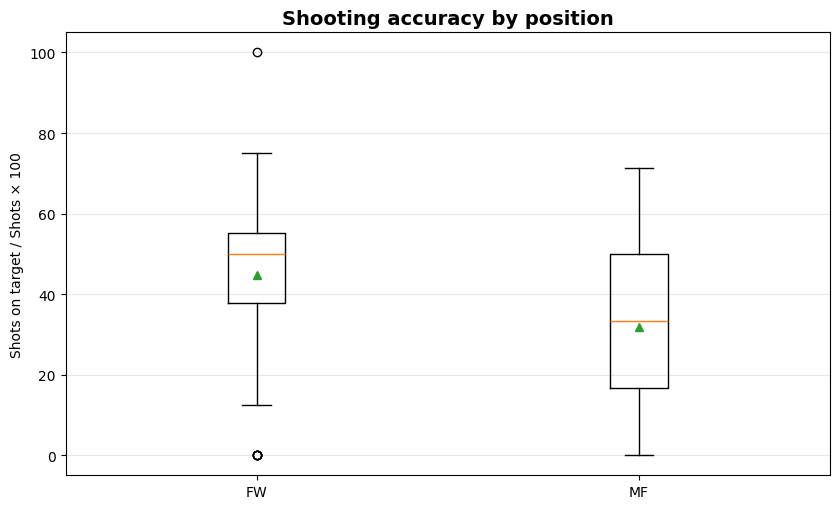

In [5]:

# Analytic question: Do forwards have higher shooting accuracy than midfielders among shooting-involved players?
players_shooting = player_standard[['Player', 'Pos', 'Squad', 'Age', 'Min', '90s']].merge(
    player_shooting[['Player', 'Squad', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90']],
    on=['Player', 'Squad'], validate='one_to_one'
)
players_shooting['PrimaryPos'] = players_shooting['Pos'].astype(str).str.split(',').str[0]
players_shooting['ShootingAccuracy'] = np.where(players_shooting['Sh'] > 0, players_shooting['SoT'] / players_shooting['Sh'] * 100, np.nan)
players_shooting['AccuracyCheckAbsDiff'] = (players_shooting['ShootingAccuracy'] - players_shooting['SoT%']).abs()

# Population: all outfield players in the 2026 World Cup. Sampling frame: FW/MF players with >=180 minutes and >=3 shots.
task2_eligible = players_shooting[
    players_shooting['PrimaryPos'].isin(['FW', 'MF']) &
    (players_shooting['Min'] >= 180) &
    (players_shooting['Sh'] >= 3) &
    players_shooting['ShootingAccuracy'].notna()
].copy()
print('Maximum absolute difference between recalculated shooting accuracy and FBref SoT%:', round(task2_eligible['AccuracyCheckAbsDiff'].max(), 3))
print('Eligible records by group:')
display(task2_eligible['PrimaryPos'].value_counts())

# Sampling method: stratified random sample of 50 forwards and 50 midfielders.
task2_sample = stratified_sample(task2_eligible, 'PrimaryPos', 50)
task2_sample.to_csv(PROC/'task2_player_shooting_accuracy.csv', index=False)

result_task2 = run_inference(task2_sample, 'PrimaryPos', 'ShootingAccuracy', ['FW', 'MF'])
print('Descriptive statistics')
display(result_task2['descriptive'])
print('95% CI - Forwards')
display(result_task2['ci_group1'])
print('95% CI - Midfielders')
display(result_task2['ci_group2'])
print('95% CI - mean difference (FW - MF)')
display(result_task2['ci_difference'])
print('Welch two-sample t-test')
display(result_task2['ttest'])
print('Assumption checks')
display(result_task2['assumptions'])
print('Sensitivity check')
display(result_task2['sensitivity'])
save_boxplot(task2_sample, 'PrimaryPos', 'ShootingAccuracy', 'Shooting accuracy by position', 'Shots on target / Shots × 100', ['FW','MF'], FIG/'task2_boxplot.png')
